<a href="https://colab.research.google.com/github/hmnaz213/native/blob/main/prepaid_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import os
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define the directory path
directory_path = '/content/drive/MyDrive/cleaned_edsa_prepaid'

# Check if directory exists and list files
dataframes = {}
if os.path.exists(directory_path):
    files = os.listdir(directory_path)
    print(f"Found {len(files)} files in {directory_path}:")

    for file in files:
        if file.endswith('.xlsx'):
            file_path = os.path.join(directory_path, file)
            print(f"Loading {file}...")
            # Load each excel file without treating the first row as a header
            df = pd.read_excel(file_path, header=None)
            dataframes[file] = df

    print("\nAll files loaded successfully!")
    print(f"Total loaded: {len(dataframes)} files.")
else:
    print(f"Directory not found: {directory_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 20 files in /content/drive/MyDrive/cleaned_edsa_prepaid:
Loading Copy of Prepaid_Sales_Details Dist 81 August2025.xlsx...
Loading Copy of Prepaid_Sales_Details Dist 81 Jan 2025.xlsx...
Loading Copy of Prepaid_Sales_Details Dist 81 May 2025.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 April2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 August2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 Feb2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 July2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 June2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 March2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79 May2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 79Jan2024.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 81 Feb2025.xlsx...
Loading Copy of Prepaid_Sales_DetailsDist 81 June 2025.xlsx.

In [3]:
schemas = {}

# Group files by their column names
for filename, df in dataframes.items():
    # Convert column list to a tuple so it can be used as a dictionary key
    cols = tuple(df.columns.astype(str))
    if cols not in schemas:
        schemas[cols] = []
    schemas[cols].append(filename)

# Display the results
print(f"Found {len(schemas)} unique schema(s) across {len(dataframes)} files.\n")

for i, (cols, files) in enumerate(schemas.items(), 1):
    print(f"--- Schema Group {i} ---")
    print(f"Number of columns: {len(cols)}")
    print(f"Columns: {list(cols)}")
    print(f"Files with this schema ({len(files)}):")
    for f in files:
        print(f"  - {f}")
    print("\n" + "="*50 + "\n")

Found 20 unique schema(s) across 20 files.

--- Schema Group 1 ---
Number of columns: 19
Columns: ['2025-08-31 23:56:44', '15356794', 'Processed', '1001510338', 'MP250831.2357.A28058', 'SINGLE PHASE PREPAID', '100036', 'Pre - Orange', '54180173533', '50', '0', '50.1', '9.5', '52329886328236', '2025-08-31 23:56:46', '2', 'Orange', 'T1-Residential  - Prepayment', '81-FREETOWN WEST']
Files with this schema (1):
  - Copy of Prepaid_Sales_Details Dist 81 August2025.xlsx


--- Schema Group 2 ---
Number of columns: 19
Columns: ['2025-01-31 23:59:55', '11679733', 'Processed', '1001419227', 'MP250201.0001.B48663', 'THREE PHASE PREPAID', '100036', 'Pre - Orange', '25700218651', '20', '0', '20.1', '3.2', '10331953092719', '2025-01-31 23:59:57', '2', 'Orange', 'T2-Commercial â€“ Prepayment', '81-FREETOWN WEST']
Files with this schema (1):
  - Copy of Prepaid_Sales_Details Dist 81 Jan 2025.xlsx


--- Schema Group 3 ---
Number of columns: 19
Columns: ['2025-05-31 23:58:39', '13720539', 'Processed', 

In [5]:
# Combine all dataframes into one
print("Concatenating dataframes...")
combined_df = pd.concat(dataframes.values(), ignore_index=True)

# Based on the sample data, let's assign descriptive column names
inferred_columns = [
    'Transaction_Date', 'Record_ID', 'Status', 'Account_Number', 'Receipt_Reference',
    'Meter_Type', 'Vendor_ID', 'Vendor_Platform', 'Phone_Number', 'Amount',
    'Surcharge_or_Tax', 'Total_Amount', 'Units_kWh', 'Token', 'Processed_Date',
    'Unknown_ID', 'Provider', 'Tariff_Type', 'District'
]

# Apply the column names if the lengths match
if len(combined_df.columns) == len(inferred_columns):
    combined_df.columns = inferred_columns
    print("Descriptive column names applied successfully.")
else:
    print(f"Warning: Expected {len(inferred_columns)} columns, but found {len(combined_df.columns)}.")

print(f"\nCombined DataFrame shape: {combined_df.shape}")

Concatenating dataframes...
Descriptive column names applied successfully.

Combined DataFrame shape: (408554, 19)


In [6]:
# Clean and normalize data types
print("Normalizing data types...")

# 1. Convert date columns to datetime objects
date_cols = ['Transaction_Date', 'Processed_Date']
for col in date_cols:
    combined_df[col] = pd.to_datetime(combined_df[col], errors='coerce')

# 2. Convert appropriate columns to numeric (float)
numeric_cols = ['Amount', 'Surcharge_or_Tax', 'Total_Amount', 'Units_kWh']
for col in numeric_cols:
    combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')

# 3. Clean string columns (strip extra whitespace and standardize)
string_cols = ['Status', 'Meter_Type', 'Vendor_Platform', 'Provider', 'Tariff_Type', 'District']
for col in string_cols:
    # Only apply string methods to rows that aren't null
    combined_df[col] = combined_df[col].astype(str).str.strip()

# View the final dataset structure
print("\n--- Dataset Info ---")
combined_df.info()

# Preview the cleaned data
display(combined_df.head())

Normalizing data types...

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 408554 entries, 0 to 408553
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Transaction_Date   408554 non-null  datetime64[ns]
 1   Record_ID          408554 non-null  int64         
 2   Status             408554 non-null  object        
 3   Account_Number     408554 non-null  int64         
 4   Receipt_Reference  408554 non-null  object        
 5   Meter_Type         408554 non-null  object        
 6   Vendor_ID          408554 non-null  int64         
 7   Vendor_Platform    408554 non-null  object        
 8   Phone_Number       408554 non-null  int64         
 9   Amount             408554 non-null  float64       
 10  Surcharge_or_Tax   408554 non-null  int64         
 11  Total_Amount       408554 non-null  float64       
 12  Units_kWh          408554 non-null  float64       
 

,Transaction_Date,Record_ID,Status,Account_Number,Receipt_Reference,Meter_Type,Vendor_ID,Vendor_Platform,Phone_Number,Amount,Surcharge_or_Tax,Total_Amount,Units_kWh,Token,Processed_Date,Unknown_ID,Provider,Tariff_Type,District
0,2025-08-31 23:56:44,15356794,Processed,1001510338,MP250831.2357.A28058,SINGLE PHASE PREPAID,100036,Pre - Orange,54180173533,50.0,0,50.1,9.5,52329886328236,2025-08-31 23:56:46,2,Orange,T1-Residential - Prepayment,81-FREETOWN WEST
1,2025-08-31 23:56:24,15356792,Processed,1001526647,MP250831.2356.B24757,SINGLE PHASE PREPAID,100036,Pre - Orange,54180185537,70.0,0,70.0,14.4,41646641778891,2025-08-31 23:56:25,1,Orange,T1-Residential - Prepayment,81-FREETOWN WEST
2,2025-08-31 23:47:22,15356756,Processed,500646989,MP250831.2347.B24498,SINGLE PHASE PREPAID,100036,Pre - Orange,25114807735,319.0,0,319.0,60.5,66045970214959,2025-08-31 23:47:24,2,Orange,T1-Residential - Prepayment,81-FREETOWN WEST
3,2025-08-31 23:45:52,15356751,Processed,1001522101,MP250831.2346.A27709,SINGLE PHASE PREPAID,100036,Pre - Orange,25112829004,200.0,0,200.0,41.2,25256743588281,2025-08-31 23:45:54,2,Orange,T1-Residential - Prepayment,81-FREETOWN WEST
4,2025-08-31 23:42:42,15356734,Processed,500086376,MP250831.2343.B24339,SINGLE PHASE PREPAID,100036,Pre - Orange,25115093988,20.0,0,20.0,4.1,83825935989849,2025-08-31 23:42:44,2,Orange,T1-Residential - Prepayment,81-FREETOWN WEST


# Task
Perform a comprehensive anomaly detection and revenue protection analysis on EDSA prepaid meter data. This involves exploratory data analysis, dormancy tracking, detecting unusual spikes or drops in consumption, profiling erratic or low-purchase patterns, and consolidating these flags into a final risk score for each account to guide field investigations.

## Exploratory Data Analysis

### Subtask:
Perform foundational EDA to understand the distribution of transaction amounts, purchase frequencies, and typical behaviors segmented by Tariff Type and Meter Type. We will also visualize the overall purchase trends.


**Reasoning**:
Generate the EDA code to calculate statistics, aggregate data by tariff and meter types, and visualize the findings.



--- Summary Statistics ---


,Amount,Total_Amount,Units_kWh
count,408554.000000,408554.000000,408554.000000
mean,216.739171,216.660287,40.428129
std,757.192387,757.185678,132.496135
min,6.000000,6.000000,2.200000
25%,50.000000,50.000000,9.300000
50%,80.000000,80.000000,14.400000
75%,130.000000,130.000000,24.700000
max,40000.000000,40000.000000,7587.800000



--- Average Purchase by Tariff and Meter Type ---


,Tariff_Type,Meter_Type,Amount,Units_kWh
0,T1-Residential - Prepayment,SINGLE PHASE PREPAID,154.949074,30.429402
1,T1-Residential - Prepayment,THREE PHASE PREPAID,752.390253,145.048295
2,T2-Commercial â€“ Prepayment,SINGLE PHASE PREPAID,375.292885,58.454408
3,T2-Commercial â€“ Prepayment,THREE PHASE PREPAID,1233.214217,194.359089
4,T3-Institutions â€“ Prepayment,SINGLE PHASE PREPAID,323.621870,51.915626
5,T3-Institutions â€“ Prepayment,THREE PHASE PREPAID,640.069465,103.909407
6,T4-MDI â€“ Prepayment,SINGLE PHASE PREPAID,2244.687500,333.016964
7,T4-MDI â€“ Prepayment,THREE PHASE PREPAID,5855.852113,866.410915
8,T7-Welders â€“ Prepayment,SINGLE PHASE PREPAID,89.729351,14.650074
9,T7-Welders â€“ Prepayment,THREE PHASE PREPAID,107.872549,18.089020


/tmp/ipykernel_3320/3734719257.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tariff_totals, x='Tariff_Type', y='Amount', ax=axes[0], palette='viridis')
/tmp/ipykernel_3320/3734719257.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tariff_totals, x='Tariff_Type', y='Units_kWh', ax=axes[1], palette='viridis')


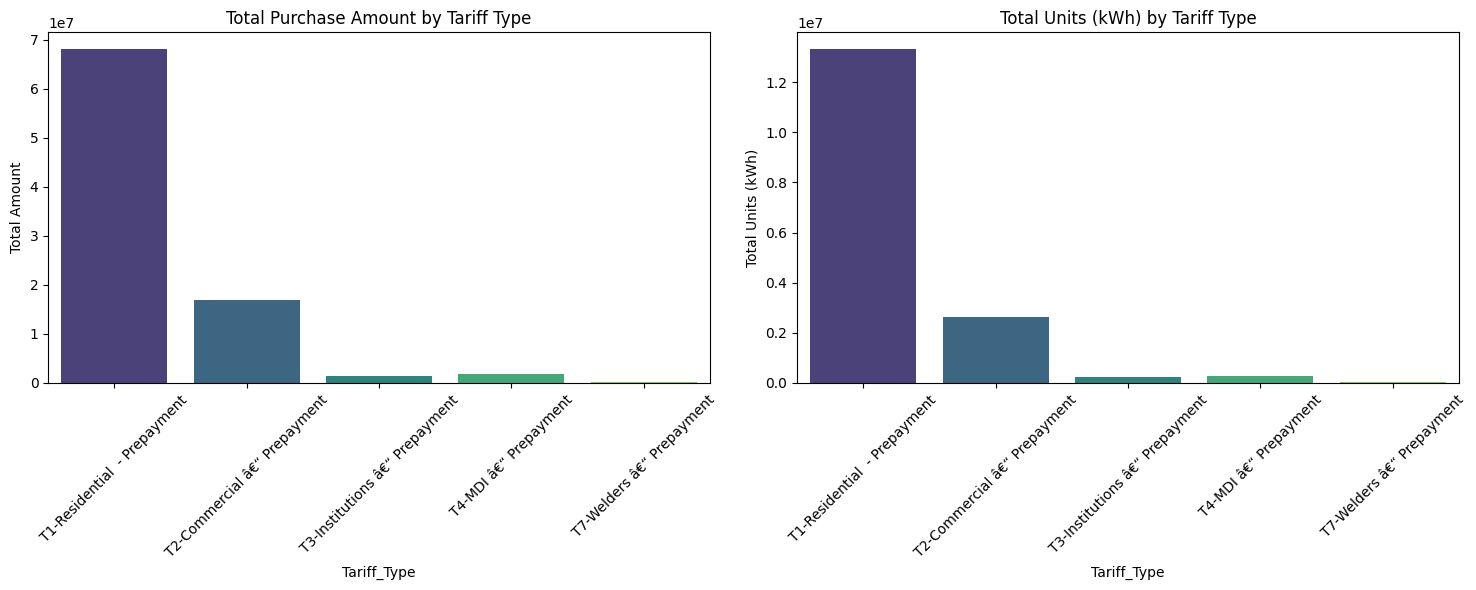

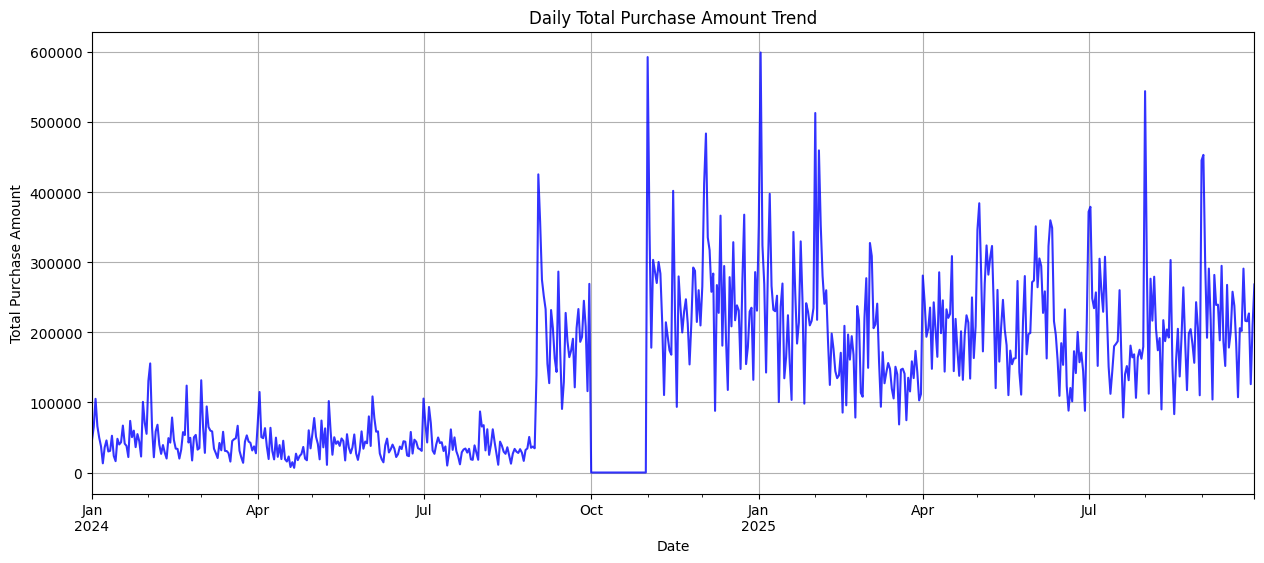

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary Statistics
print("--- Summary Statistics ---")
display(combined_df[['Amount', 'Total_Amount', 'Units_kWh']].describe())

# 2. Group by Tariff_Type and Meter_Type
print("\n--- Average Purchase by Tariff and Meter Type ---")
grouped_stats = combined_df.groupby(['Tariff_Type', 'Meter_Type'])[['Amount', 'Units_kWh']].mean().reset_index()
display(grouped_stats)

# 3. Bar chart: Total Amount and Units per Tariff Type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
tariff_totals = combined_df.groupby('Tariff_Type')[['Amount', 'Units_kWh']].sum().reset_index()

sns.barplot(data=tariff_totals, x='Tariff_Type', y='Amount', ax=axes[0], palette='viridis')
axes[0].set_title('Total Purchase Amount by Tariff Type')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Total Amount')

sns.barplot(data=tariff_totals, x='Tariff_Type', y='Units_kWh', ax=axes[1], palette='viridis')
axes[1].set_title('Total Units (kWh) by Tariff Type')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Total Units (kWh)')

plt.tight_layout()
plt.show()

# 4. Overall daily purchase trend
plt.figure(figsize=(15, 6))
# Ensure Transaction_Date is sorted before resampling
daily_trend = combined_df.set_index('Transaction_Date').sort_index().resample('D')['Amount'].sum()
daily_trend.plot(kind='line', color='blue', alpha=0.8)
plt.title('Daily Total Purchase Amount Trend')
plt.xlabel('Date')
plt.ylabel('Total Purchase Amount')
plt.grid(True)
plt.show()


**Reasoning**:
Fix the FutureWarning in seaborn by explicitly setting 'hue' to match 'x' and disabling the legend.



--- Summary Statistics ---


,Amount,Total_Amount,Units_kWh
count,408554.000000,408554.000000,408554.000000
mean,216.739171,216.660287,40.428129
std,757.192387,757.185678,132.496135
min,6.000000,6.000000,2.200000
25%,50.000000,50.000000,9.300000
50%,80.000000,80.000000,14.400000
75%,130.000000,130.000000,24.700000
max,40000.000000,40000.000000,7587.800000



--- Average Purchase by Tariff and Meter Type ---


,Tariff_Type,Meter_Type,Amount,Units_kWh
0,T1-Residential - Prepayment,SINGLE PHASE PREPAID,154.949074,30.429402
1,T1-Residential - Prepayment,THREE PHASE PREPAID,752.390253,145.048295
2,T2-Commercial â€“ Prepayment,SINGLE PHASE PREPAID,375.292885,58.454408
3,T2-Commercial â€“ Prepayment,THREE PHASE PREPAID,1233.214217,194.359089
4,T3-Institutions â€“ Prepayment,SINGLE PHASE PREPAID,323.621870,51.915626
5,T3-Institutions â€“ Prepayment,THREE PHASE PREPAID,640.069465,103.909407
6,T4-MDI â€“ Prepayment,SINGLE PHASE PREPAID,2244.687500,333.016964
7,T4-MDI â€“ Prepayment,THREE PHASE PREPAID,5855.852113,866.410915
8,T7-Welders â€“ Prepayment,SINGLE PHASE PREPAID,89.729351,14.650074
9,T7-Welders â€“ Prepayment,THREE PHASE PREPAID,107.872549,18.089020


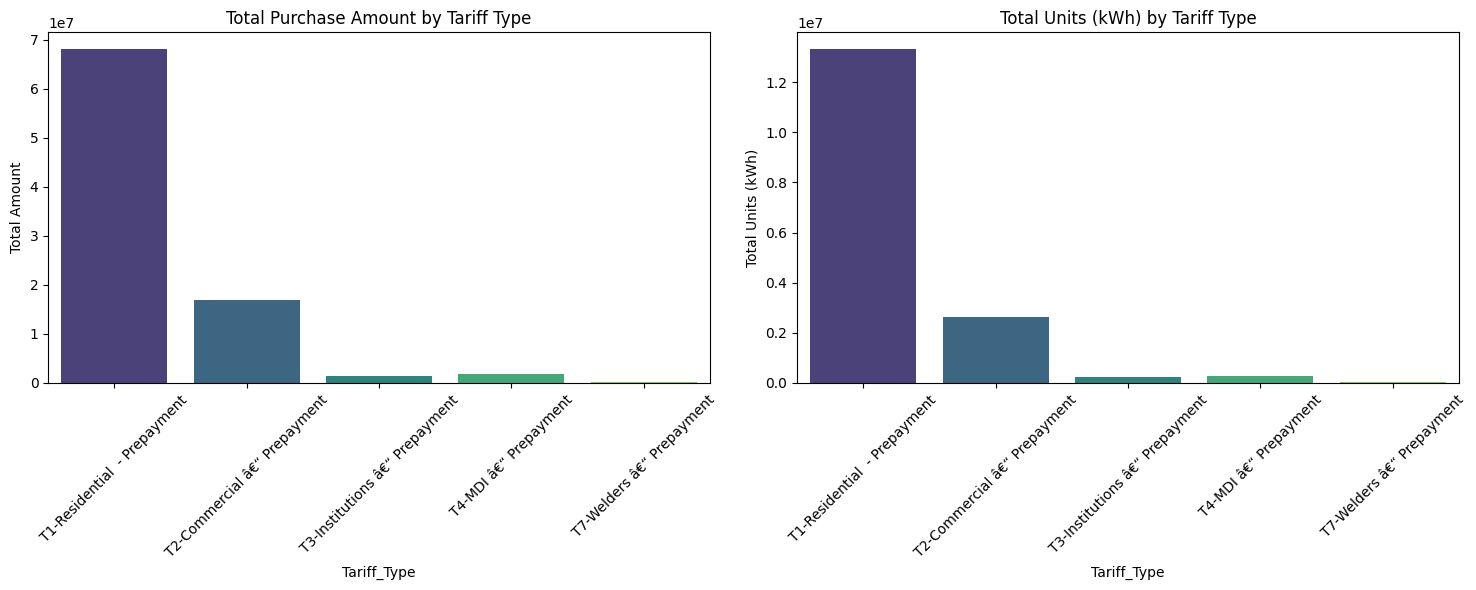

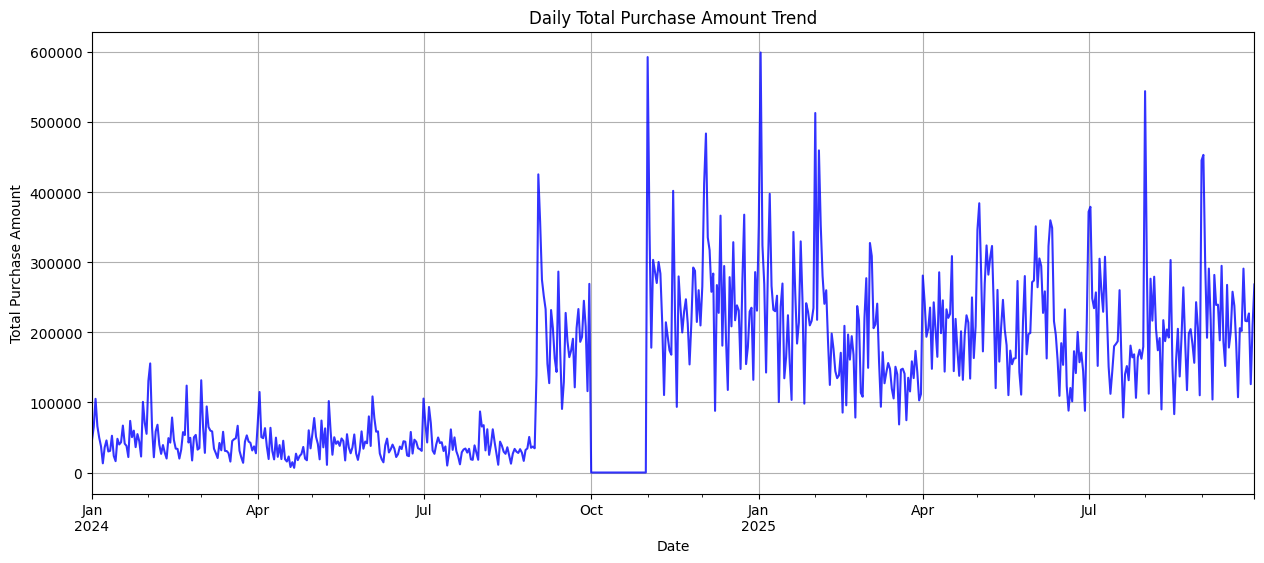

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Summary Statistics
print("--- Summary Statistics ---")
display(combined_df[['Amount', 'Total_Amount', 'Units_kWh']].describe())

# 2. Group by Tariff_Type and Meter_Type
print("\n--- Average Purchase by Tariff and Meter Type ---")
grouped_stats = combined_df.groupby(['Tariff_Type', 'Meter_Type'])[['Amount', 'Units_kWh']].mean().reset_index()
display(grouped_stats)

# 3. Bar chart: Total Amount and Units per Tariff Type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
tariff_totals = combined_df.groupby('Tariff_Type')[['Amount', 'Units_kWh']].sum().reset_index()

sns.barplot(data=tariff_totals, x='Tariff_Type', y='Amount', ax=axes[0], hue='Tariff_Type', palette='viridis', legend=False)
axes[0].set_title('Total Purchase Amount by Tariff Type')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel('Total Amount')

sns.barplot(data=tariff_totals, x='Tariff_Type', y='Units_kWh', ax=axes[1], hue='Tariff_Type', palette='viridis', legend=False)
axes[1].set_title('Total Units (kWh) by Tariff Type')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Total Units (kWh)')

plt.tight_layout()
plt.show()

# 4. Overall daily purchase trend
plt.figure(figsize=(15, 6))
# Ensure Transaction_Date is sorted before resampling
daily_trend = combined_df.set_index('Transaction_Date').sort_index().resample('D')['Amount'].sum()
daily_trend.plot(kind='line', color='blue', alpha=0.8)
plt.title('Daily Total Purchase Amount Trend')
plt.xlabel('Date')
plt.ylabel('Total Purchase Amount')
plt.grid(True)
plt.show()


# Task
Perform a comprehensive anomaly detection and revenue protection analysis on EDSA prepaid meter data. This involves exploratory data analysis, dormancy tracking, detecting unusual spikes or drops in consumption, profiling erratic or low-purchase patterns, and consolidating these flags into a final risk score for each account to guide field investigations.

## Account Dormancy Tracking

### Subtask:
Calculate the time elapsed since the last purchase for each account to identify dormant or inactive accounts.


**Reasoning**:
I will calculate the time since the last purchase for each account and flag dormant accounts (e.g., > 90 days).



In [9]:
# 1. Determine the analysis date (latest date in the dataset)
analysis_date = combined_df['Transaction_Date'].max()
print(f"Analysis Date: {analysis_date}")

# 2 & 3. Group by Account_Number, find max date, and calculate days since last purchase
dormancy_df = combined_df.groupby('Account_Number')['Transaction_Date'].max().reset_index()
dormancy_df.rename(columns={'Transaction_Date': 'Last_Purchase_Date'}, inplace=True)
dormancy_df['days_since_last_purchase'] = (analysis_date - dormancy_df['Last_Purchase_Date']).dt.days

# 4. Flag accounts as dormant if they haven't purchased in > 90 days
dormancy_df['is_dormant'] = dormancy_df['days_since_last_purchase'] > 90

# Display the results
print(f"\nTotal Accounts: {len(dormancy_df)}")
print(f"Dormant Accounts (>90 days): {dormancy_df['is_dormant'].sum()}")
display(dormancy_df.head())


Analysis Date: 2025-09-30 23:59:20

Total Accounts: 17866
Dormant Accounts (>90 days): 6197


,Account_Number,Last_Purchase_Date,days_since_last_purchase,is_dormant
0,500000245,2025-06-24 21:49:38,98,True
1,500000617,2025-09-19 19:05:39,11,False
2,500001292,2024-08-16 10:00:37,410,True
3,500001391,2025-08-18 11:22:46,43,False
4,500001417,2025-09-15 11:04:10,15,False
